In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer

# ML Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# UCI Dermatology dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/dermatology/dermatology.data"

# Feature names
feature_names = [
    "erythema",
    "scaling",
    "definite_borders",
    "itching",
    "koebner_phenomenon",
    "polygonal_papules",
    "follicular_papules",
    "oral_mucosal_involvement",
    "knee_elbow_involvement",
    "scalp_involvement",
    "family_history",
    "melanin_incontinence",
    "eosinophils_infiltrate",
    "PNL_infiltrate",
    "fibrosis_papillary_dermis",
    "exocytosis",
    "acanthosis",
    "hyperkeratosis",
    "parakeratosis",
    "clubbing_rete_ridges",
    "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis",
    "spongiform_pustule",
    "munro_microabcess",
    "focal_hypergranulosis",
    "disappearance_granular_layer",
    "vacuolisation_basal_layer",
    "spongiosis",
    "saw_tooth_rete_ridges",
    "follicular_horn_plug",
    "perifollicular_parakeratosis",
    "inflammatory_monoluclear_infiltrate",
    "band_like_infiltrate",
    "age",
    "class"
]

# Load dataset
df = pd.read_csv(
    url,
    header=None,
    names=feature_names,
    na_values="?"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_basal_layer,spongiosis,saw_tooth_rete_ridges,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset Information:")
df.info()

Number of rows: 366
Number of columns: 35

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   erythema                             366 non-null    int64  
 1   scaling                              366 non-null    int64  
 2   definite_borders                     366 non-null    int64  
 3   itching                              366 non-null    int64  
 4   koebner_phenomenon                   366 non-null    int64  
 5   polygonal_papules                    366 non-null    int64  
 6   follicular_papules                   366 non-null    int64  
 7   oral_mucosal_involvement             366 non-null    int64  
 8   knee_elbow_involvement               366 non-null    int64  
 9   scalp_involvement                    366 non-null    int64  
 10  family_history                    

In [4]:
print("First 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

First 5 records:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_basal_layer,spongiosis,saw_tooth_rete_ridges,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3



Last 5 records:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_basal_layer,spongiosis,saw_tooth_rete_ridges,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3
365,3,2,2,0,0,0,0,0,3,3,...,2,0,0,0,0,0,3,0,35.0,1


In [5]:
print("Summary Statistics:")
display(df.describe().T)

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.00,3.0
knee_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.00,3.0


In [6]:
print("Median of each feature:")
display(df.median(numeric_only=True))

Median of each feature:


,0
erythema,2.0
scaling,2.0
definite_borders,2.0
itching,1.0
koebner_phenomenon,0.0
polygonal_papules,0.0
follicular_papules,0.0
oral_mucosal_involvement,0.0
knee_elbow_involvement,0.0
scalp_involvement,0.0


In [7]:
print("Standard deviation:")
display(df.std(numeric_only=True))

Standard deviation:


,0
erythema,0.664753
scaling,0.701527
definite_borders,0.907525
itching,1.138299
koebner_phenomenon,0.908016
polygonal_papules,0.957327
follicular_papules,0.570588
oral_mucosal_involvement,0.834147
knee_elbow_involvement,0.982979
scalp_involvement,0.905639


In [8]:
print("Missing values in each column:")
missing_values = df.isnull().sum()

display(missing_values[missing_values > 0])

Missing values in each column:


,0
age,8


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 8


In [10]:
# Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

# Convert all features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Median imputation
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(
    X_imputed,
    columns=X.columns
)

print("Missing values after imputation:")
print(X.isnull().sum().sum())

Missing values after imputation:
0


In [11]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (366, 35)


In [13]:
print("Class distribution:")
print(y.value_counts().sort_index())

Class distribution:
class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64


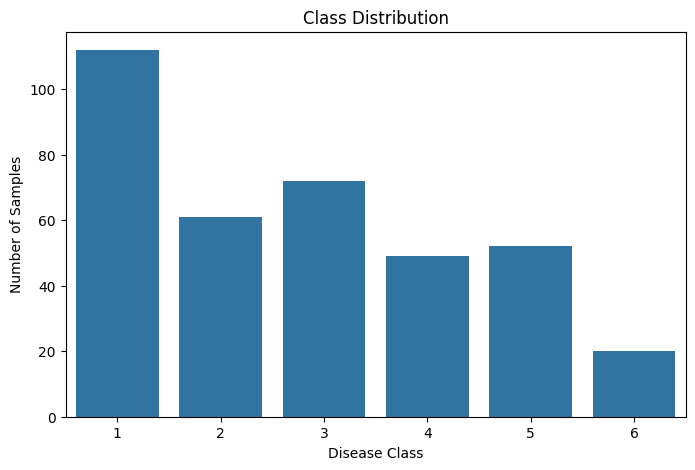

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")

plt.show()

In [15]:
class_percentage = y.value_counts(normalize=True).sort_index() * 100

print("Class percentage:")
print(class_percentage)

Class percentage:
class
1    30.601093
2    16.666667
3    19.672131
4    13.387978
5    14.207650
6     5.464481
Name: proportion, dtype: float64


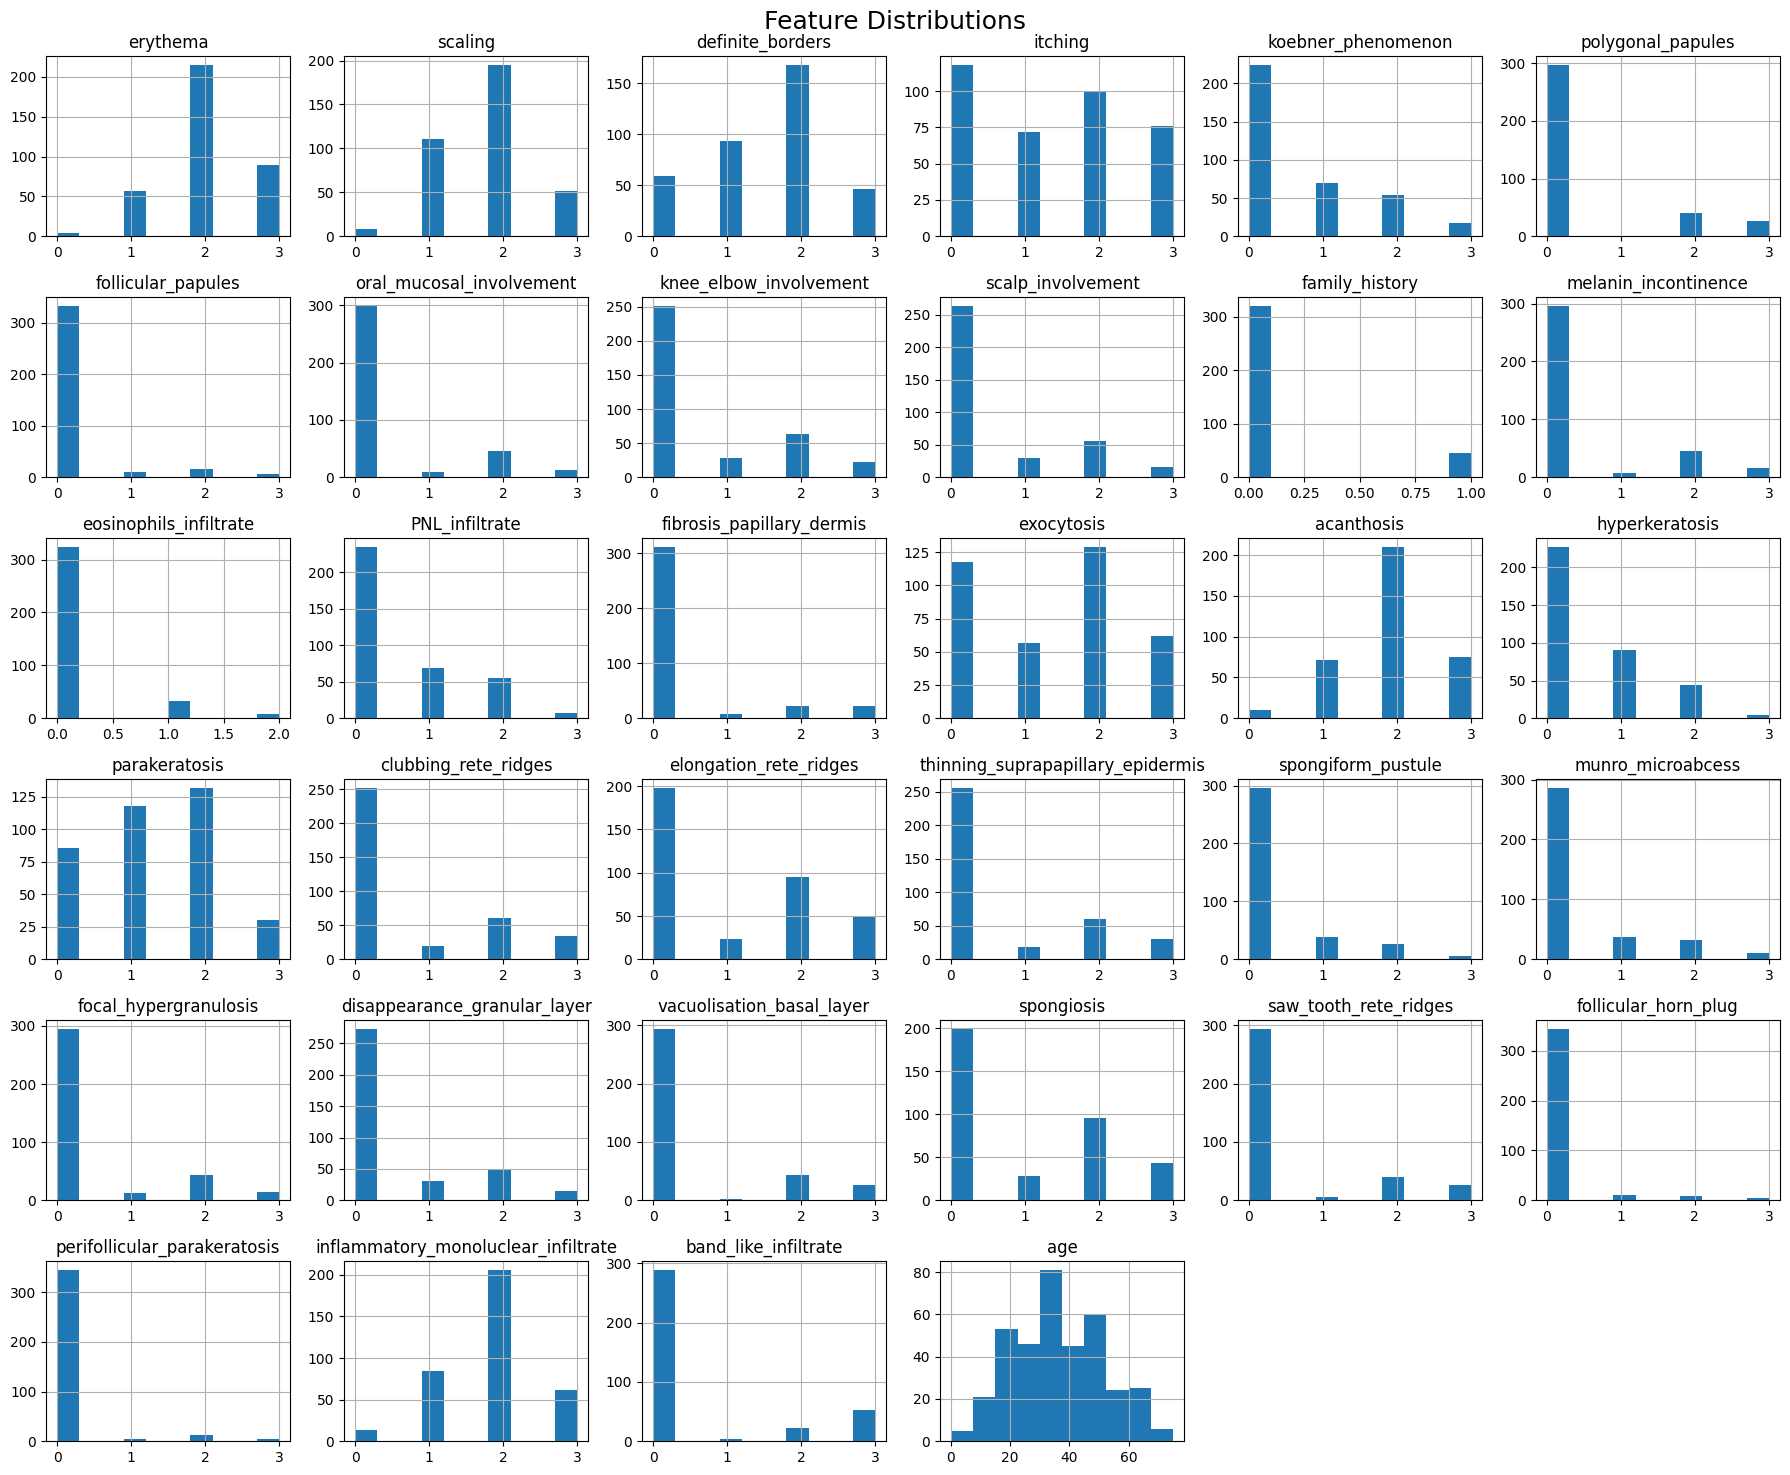

In [16]:
X.hist(
    figsize=(18, 15),
    bins=10
)

plt.suptitle("Feature Distributions", fontsize=18)
plt.tight_layout()

plt.show()

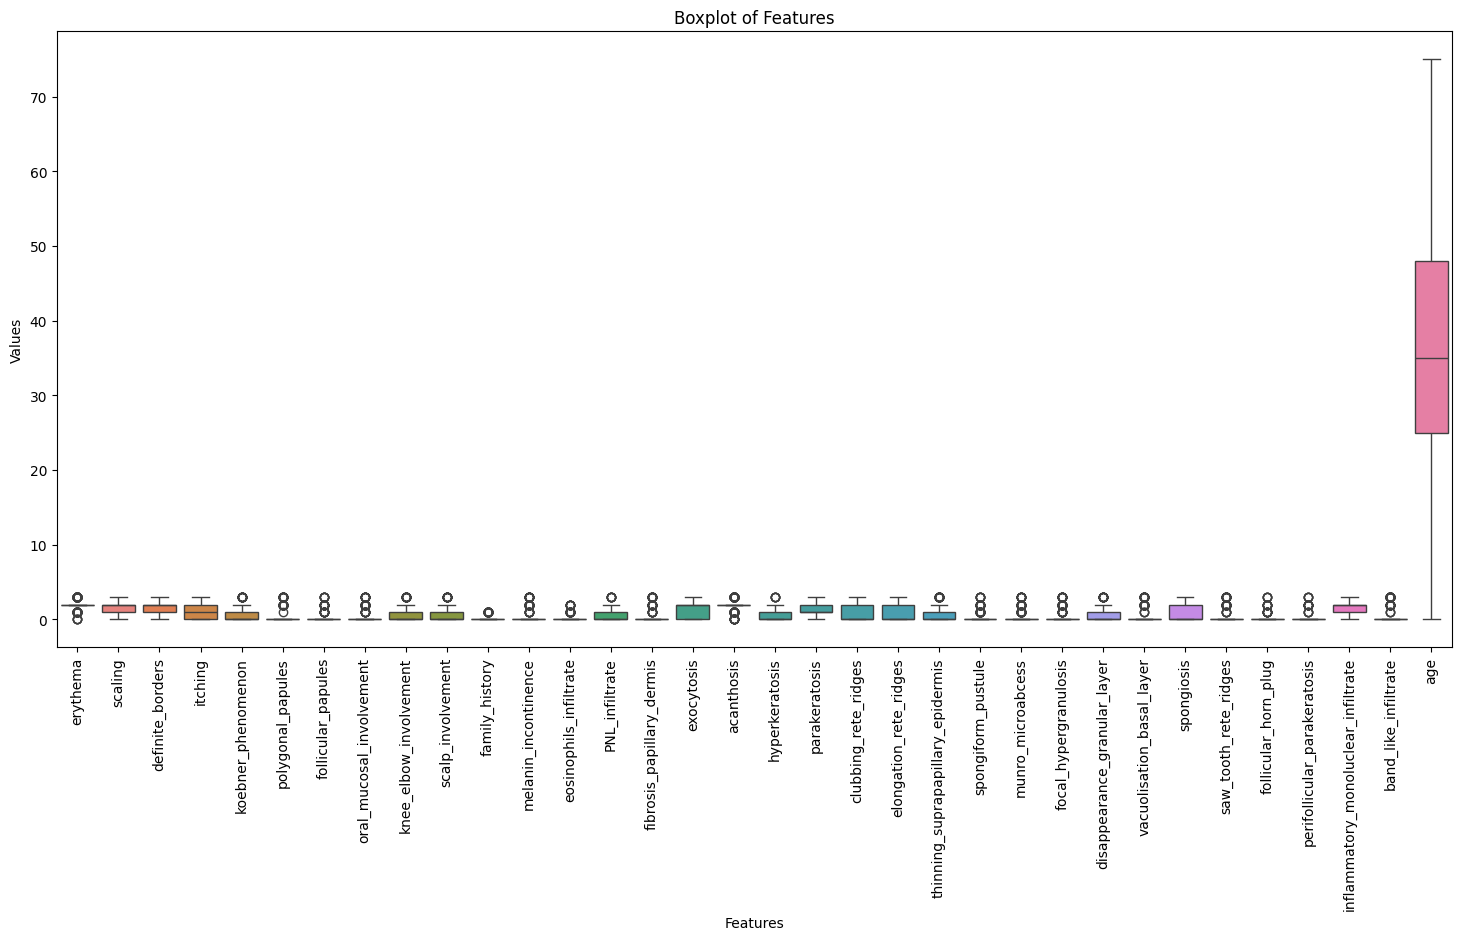

In [17]:
plt.figure(figsize=(18, 8))

sns.boxplot(data=X)

plt.xticks(rotation=90)
plt.title("Boxplot of Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

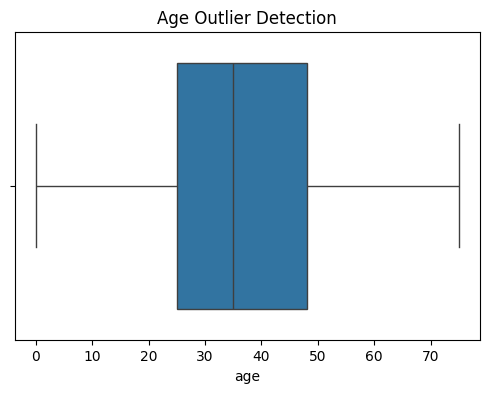

In [18]:
plt.figure(figsize=(6, 4))

sns.boxplot(x=X["age"])

plt.title("Age Outlier Detection")
plt.show()

In [19]:
Q1 = X["age"].quantile(0.25)
Q3 = X["age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X["age"] = X["age"].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Age outliers handled using IQR capping.")

Age outliers handled using IQR capping.


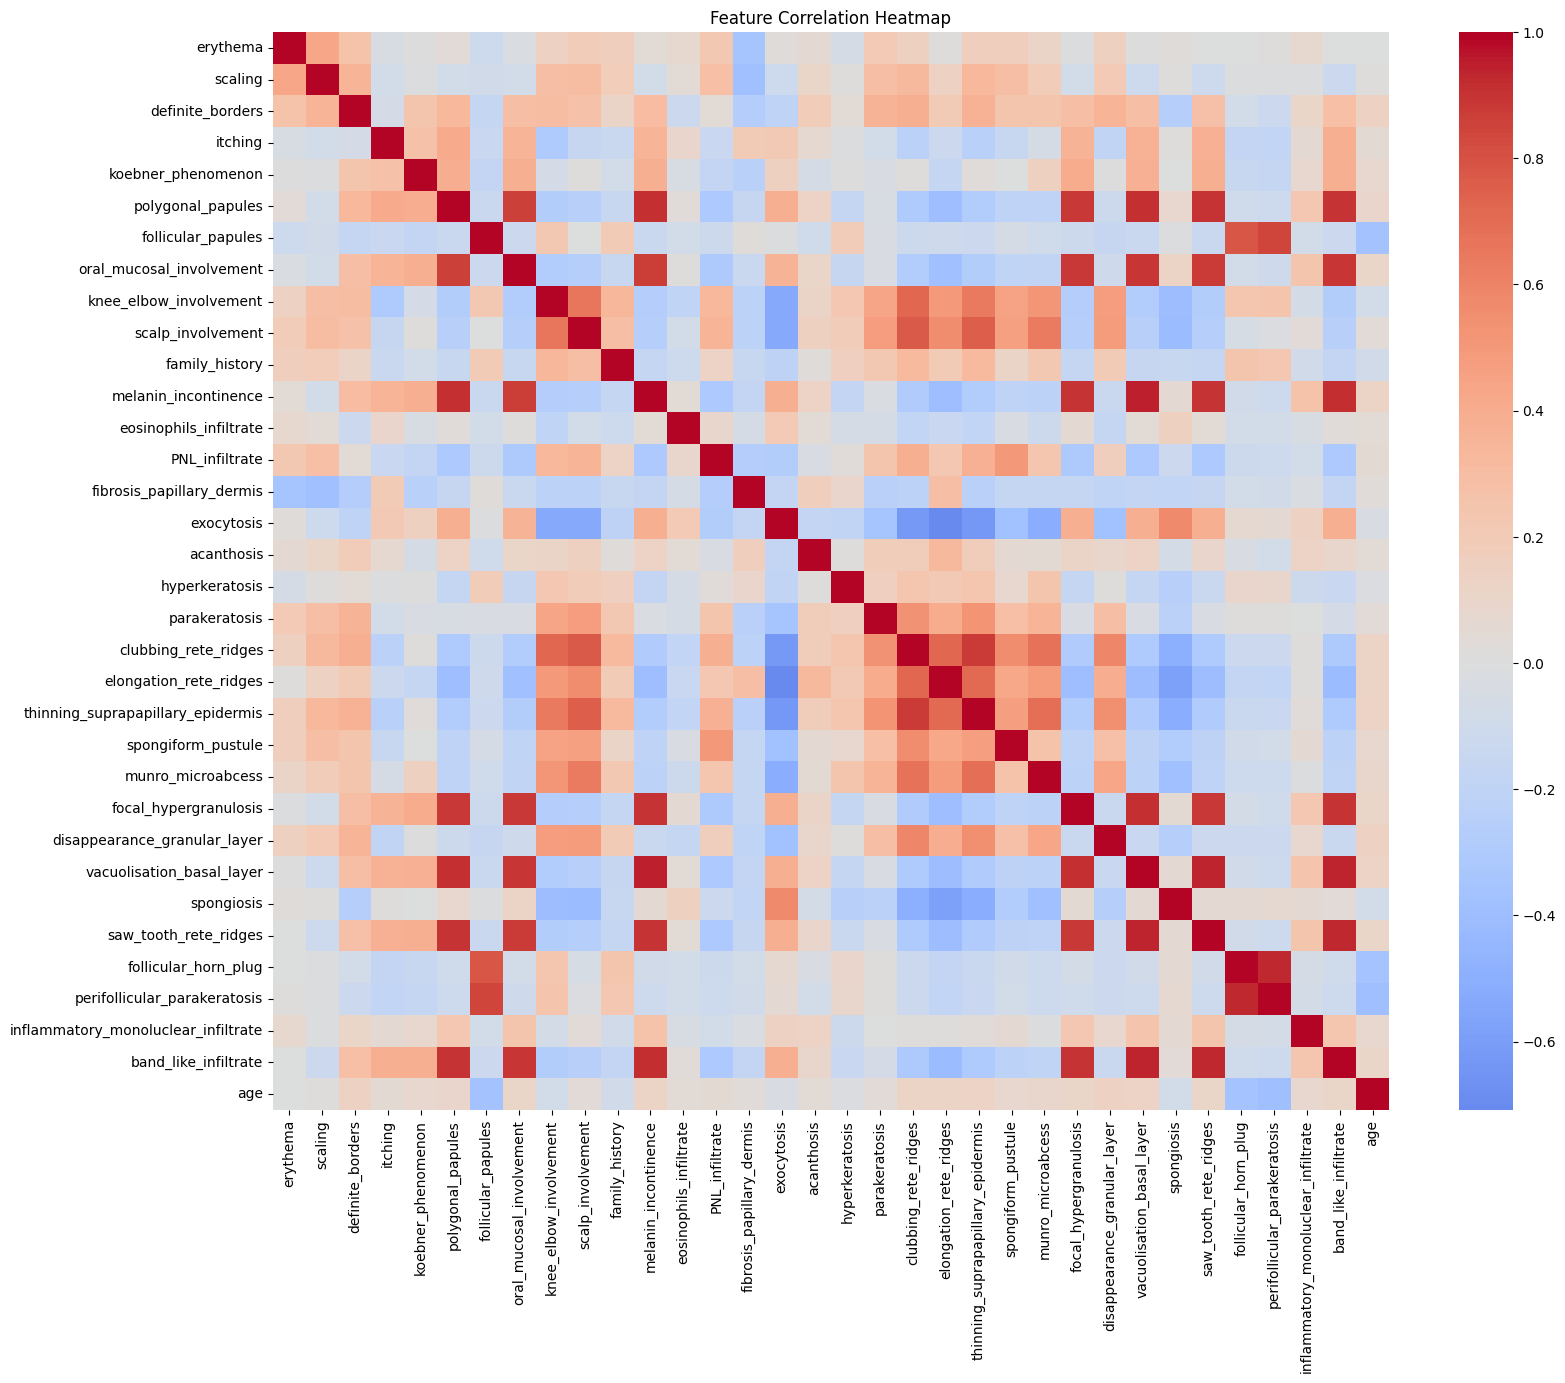

In [20]:
plt.figure(figsize=(18, 14))

correlation = X.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (292, 34)
Testing data: (74, 34)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

In [24]:
trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    print(name, "trained successfully.")

KNN trained successfully.
Random Forest trained successfully.
Logistic Regression trained successfully.
SVM trained successfully.
Decision Tree trained successfully.


In [25]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

display(results_df.sort_values(
    by="Accuracy",
    ascending=False
))

,Model,Accuracy
3,SVM,0.972973
2,Logistic Regression,0.959459
1,Random Forest,0.959459
4,Decision Tree,0.959459
0,KNN,0.905405


In [26]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            digits=4
        )
    )


KNN
              precision    recall  f1-score   support

           1     1.0000    0.9565    0.9778        23
           2     0.8000    0.6667    0.7273        12
           3     1.0000    0.9333    0.9655        15
           4     0.6429    0.9000    0.7500        10
           5     1.0000    1.0000    1.0000        10
           6     1.0000    1.0000    1.0000         4

    accuracy                         0.9054        74
   macro avg     0.9071    0.9094    0.9034        74
weighted avg     0.9193    0.9054    0.9081        74


Random Forest
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        23
           2     0.9091    0.8333    0.8696        12
           3     1.0000    1.0000    1.0000        15
           4     0.8182    0.9000    0.8571        10
           5     1.0000    1.0000    1.0000        10
           6     1.0000    1.0000    1.0000         4

    accuracy                         0.9595        74
   

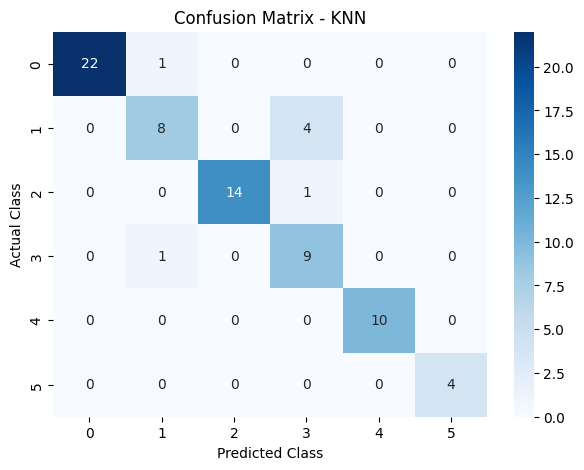

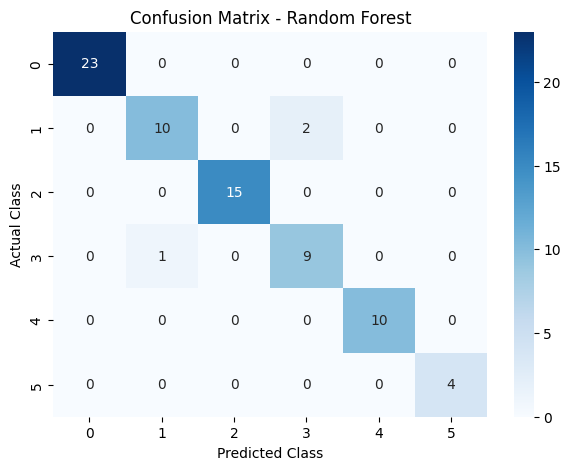

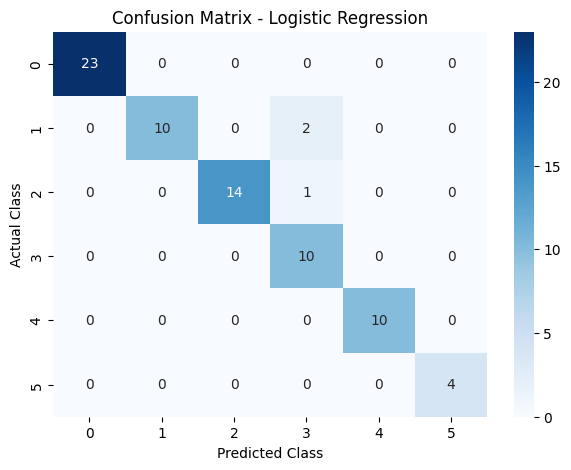

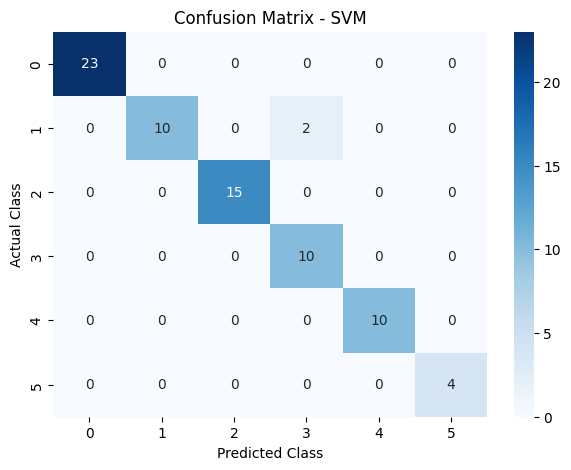

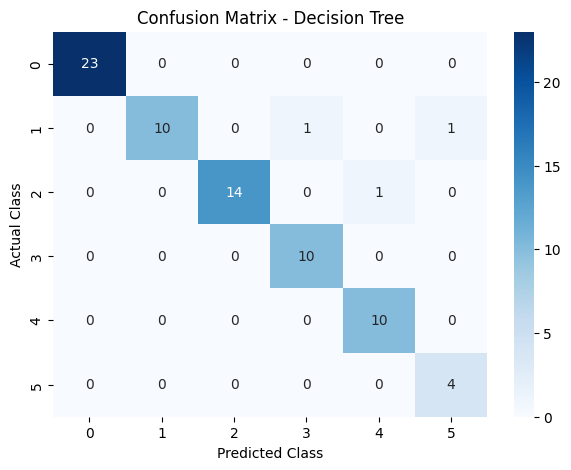

In [27]:
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

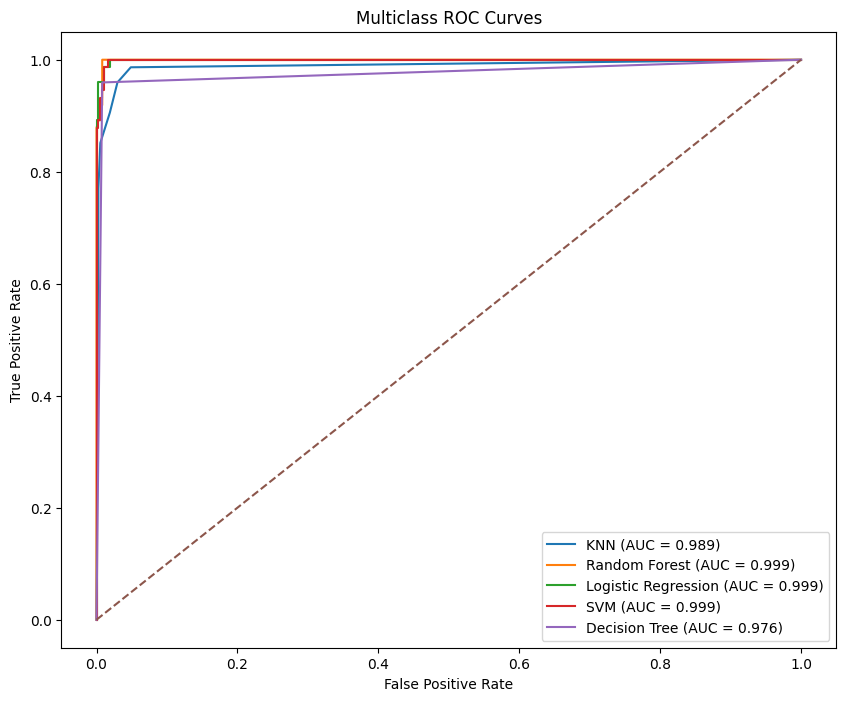

In [28]:
# Binarize target labels
classes = np.sort(y.unique())

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():

    y_score = model.predict_proba(X_test_scaled)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(len(classes)):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(
        y_test_bin.ravel(),
        y_score.ravel()
    )

    auc_micro = auc(
        fpr_micro,
        tpr_micro
    )

    plt.plot(
        fpr_micro,
        tpr_micro,
        label=f"{name} (AUC = {auc_micro:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multiclass ROC Curves")

plt.legend()

plt.show()

In [29]:
auc_results = []

for name, model in trained_models.items():

    y_score = model.predict_proba(X_test_scaled)

    auc_score = roc_auc_score(
        y_test_bin,
        y_score,
        multi_class="ovr",
        average="macro"
    )

    auc_results.append({
        "Model": name,
        "AUC": auc_score
    })

auc_df = pd.DataFrame(auc_results)

display(
    auc_df.sort_values(
        by="AUC",
        ascending=False
    )
)

,Model,AUC
2,Logistic Regression,0.999068
1,Random Forest,0.998323
3,SVM,0.998062
0,KNN,0.986262
4,Decision Tree,0.976761


In [30]:
final_results = results_df.merge(
    auc_df,
    on="Model"
)

display(
    final_results.sort_values(
        by="Accuracy",
        ascending=False
    )
)

,Model,Accuracy,AUC
3,SVM,0.972973,0.998062
2,Logistic Regression,0.959459,0.999068
1,Random Forest,0.959459,0.998323
4,Decision Tree,0.959459,0.976761
0,KNN,0.905405,0.986262


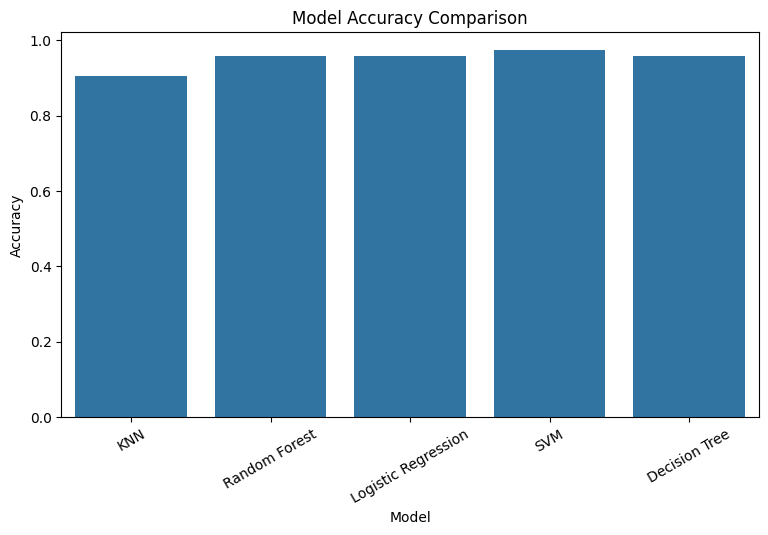

In [31]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()